# 05 - RAG Clinical Extraction for NSCLC (Phase III + FDA Safety)

This notebook demonstrates a clinician-facing RAG workflow for **non-small cell lung cancer (NSCLC)** that:

1. Reuses existing retrieval and generation methods from `src/` (same backbone as notebooks 03 and 04).
2. Answers clinically relevant mock questions about Phase III evidence.
3. Surfaces promising treatment candidates and FDA safety/counter-indication context.
4. Produces polished visual outputs and saved artifacts for portfolio presentation.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import logging
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import HTML, Markdown, display

from biotech_rag.data.fda_parser import parse_fda_json
from biotech_rag.generation.ground_truth import build_ground_truth_chains, invoke_chain_with_retries
from biotech_rag.generation.llm_clients import get_openrouter_llm
from biotech_rag.indexing.embedders import Embedder
from biotech_rag.indexing.vectorstore import init_chroma
from biotech_rag.retrieval.context_retrieval import (
    format_retrieved_chunks,
    get_collection_embedding_dim,
    retrieve_chunks,
)

In [2]:
load_dotenv()
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("nsclc_rag_extraction")

# Visual direction: clean clinical dashboard (light, high-contrast, intentional color system).
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

display(HTML(
    """
    <style>
    :root {
      --ink: #1f2a37;
      --teal: #0f766e;
      --amber: #d97706;
      --bg: linear-gradient(135deg, #f8fbff 0%, #eef8f6 100%);
      --panel: #ffffff;
    }
    .jp-Notebook, .notebook_app { background: var(--bg); }
    .clinical-card {
      background: var(--panel);
      border-left: 6px solid var(--teal);
      border-radius: 12px;
      padding: 14px 18px;
      margin: 10px 0;
      box-shadow: 0 8px 20px rgba(15, 118, 110, 0.10);
      color: var(--ink);
    }
    .clinical-chip {
      display: inline-block;
      padding: 3px 10px;
      border-radius: 999px;
      font-size: 12px;
      margin-right: 6px;
      background: #e6fffa;
      color: #115e59;
      border: 1px solid #99f6e4;
    }
    </style>
    """
))

In [3]:
# Paths and constants
DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
REPORTS_FIGURES = Path("../reports/figures")
EXTRACTIONS_DIR = DATA_PROCESSED / "extractions"

ENRICHED_PATH = DATA_PROCESSED / "enriched_master_ai_trials_dataset.csv"
RAG_READY_PATH = DATA_PROCESSED / "rag_ready_trials.csv"
VSTORE_DIR = DATA_PROCESSED / "vectorstore/chroma_db"

OUTPUT_QA_JSON = EXTRACTIONS_DIR / "nsclc_rag_extraction_answers.json"
OUTPUT_QA_CSV = EXTRACTIONS_DIR / "nsclc_rag_extraction_answers.csv"
OUTPUT_RANKING_CSV = EXTRACTIONS_DIR / "nsclc_phase3_drug_ranking.csv"
OUTPUT_SAFETY_CSV = EXTRACTIONS_DIR / "nsclc_fda_safety_summary.csv"
OUTPUT_FIG_EFFICACY = REPORTS_FIGURES / "05_nsclc_promising_candidates.png"
OUTPUT_FIG_SAFETY = REPORTS_FIGURES / "05_nsclc_safety_signals.png"

TOP_K = 10
RANDOM_SEED = 42

EXTRACTIONS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

In [4]:
# Reuse notebook-03 style initialization for retrieval + extraction
llm_ready = False
retrieval_ready = False

try:
    llm = get_openrouter_llm(model="openai/gpt-4o-mini:floor")
    chains = build_ground_truth_chains(llm)
    draft_parser = chains["draft_parser"]
    draft_chain_raw = chains["draft_chain_raw"]
    llm_ready = True
    logger.info("LLM and extraction chains initialized.")
except Exception as exc:
    logger.warning(f"LLM initialization failed: {exc}")

try:
    client, collection = init_chroma(VSTORE_DIR, collection_name="clinical_trials")
    embedder = Embedder()
    collection_dim = get_collection_embedding_dim(collection)
    retrieval_ready = True
    logger.info(f"Embedder backend={embedder.backend} model={embedder.model}")
    logger.info(f"Chroma count={collection.count()} | embedding_dim={collection_dim}")
except Exception as exc:
    logger.error(f"Retrieval initialization failed: {exc}")

if not retrieval_ready:
    raise RuntimeError("Vectorstore retrieval is required for this notebook. Check Chroma path and embeddings.")

INFO:nsclc_rag_extraction:LLM and extraction chains initialized.
INFO:chromadb.telemetry.product.posthog:Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
INFO:nsclc_rag_extraction:Embedder backend=openrouter model=qwen/qwen3-embedding-8b:floor
INFO:nsclc_rag_extraction:Chroma count=5532 | embedding_dim=4096


In [5]:
# Load structured trial datasets and isolate Phase III NSCLC
enriched_df = pd.read_csv(ENRICHED_PATH)
rag_ready_df = pd.read_csv(RAG_READY_PATH)

def pick_first(cols, candidates):
    for candidate in candidates:
        if candidate in cols:
            return candidate
    return None

phase_col = pick_first(enriched_df.columns, ["phase"])
condition_col = pick_first(enriched_df.columns, ["condition_name", "condition"])

phase_mask = enriched_df[phase_col].astype(str).str.contains(r"phase\s*3|phaseiii|phase3|PHASE3", case=False, na=False)
nsclc_mask = enriched_df[condition_col].astype(str).str.contains(r"non[-\s]?small cell lung cancer|nsclc", case=False, na=False)
phase3_nsclc_df = enriched_df[phase_mask & nsclc_mask].copy()

display(HTML(
    f"""
    <div class='clinical-card'>
      <span class='clinical-chip'>Trials in enriched dataset: {len(enriched_df)}</span>
      <span class='clinical-chip'>Phase III NSCLC trials: {len(phase3_nsclc_df)}</span>
      <span class='clinical-chip'>RAG-ready rows: {len(rag_ready_df)}</span>
    </div>
    """
))

phase3_nsclc_df[["nct_id", "brief_title", "overall_status", "intervention_name", "success_flag"]].head(5)

,nct_id,brief_title,overall_status,intervention_name,success_flag
0,NCT04205812,Platinum-Based Chemotherapy With/Without INCMG...,ACTIVE_NOT_RECRUITING,nab-Paclitaxel,LIKELY_PASS
1,NCT04194944,A Study of Selpercatinib (LY3527723) in Partic...,ACTIVE_NOT_RECRUITING,Selpercatinib,LIKELY_PASS
2,NCT03594747,A Study of Tislelizumab in Combination With Ch...,COMPLETED,Tislelizumab,LIKELY_PASS
3,NCT03663205,A Study Evaluating the Efficacy and Safety of ...,COMPLETED,Pemetrexed,LIKELY_PASS
4,NCT04035486,A Study of Osimertinib With or Without Chemoth...,ACTIVE_NOT_RECRUITING,Osimertinib,LIKELY_PASS


In [6]:
# Clinically relevant mock questions for physicians/researchers
clinical_questions = [
    "What does the latest Phase III evidence in this dataset suggest about the treatment landscape for advanced NSCLC?",
    "Which NSCLC therapies show the strongest efficacy signals in Phase III, and which endpoints support that?",
    "For EGFR-mutated NSCLC, which drugs appear most promising and what data supports this?",
    "For RET fusion-positive NSCLC, what evidence supports selpercatinib or alternatives in Phase III?",
    "Which immunotherapy combinations improved OS or PFS in Phase III NSCLC and in what patient subgroups?",
    "What are the most clinically relevant grade 3 or higher adverse events reported in the strongest NSCLC trials?",
    "What FDA warnings, precautions, and adverse-reaction signals should clinicians review for top NSCLC drug candidates?",
]

question_df = pd.DataFrame({"question_id": range(1, len(clinical_questions) + 1), "question": clinical_questions})
question_df

,question_id,question
0,1,What does the latest Phase III evidence in thi...
1,2,Which NSCLC therapies show the strongest effic...
2,3,"For EGFR-mutated NSCLC, which drugs appear mos..."
3,4,"For RET fusion-positive NSCLC, what evidence s..."
4,5,Which immunotherapy combinations improved OS o...
5,6,What are the most clinically relevant grade 3 ...
6,7,"What FDA warnings, precautions, and adverse-re..."


In [7]:
def _first_result_list(results, key):
    values = results.get(key, []) if isinstance(results, dict) else []
    if not isinstance(values, list) or len(values) == 0:
        return []
    first = values[0]
    return first if isinstance(first, list) else values


def _clean_text(text, max_len=1200):
    text = re.sub(r"\s+", " ", str(text)).strip()
    return text[:max_len] + ("..." if len(text) > max_len else "")


def _split_candidate_terms(raw_name):
    parts = re.split(r",|/|;|\+|\band\b|\bwith\b", str(raw_name), flags=re.I)
    return [p.strip() for p in parts if p and p.strip()]


def _build_known_drug_terms(df):
    candidate_cols = [
        c
        for c in [
            "intervention_name_extracted",
            "intervention_name",
            "fda_generic_name",
            "fda_brand_name",
        ]
        if c in df.columns
    ]

    stop_terms = {
        "nan",
        "none",
        "placebo",
        "chemotherapy",
        "standard of care",
        "best supportive care",
    }

    terms = []
    for col in candidate_cols:
        for value in df[col].dropna().astype(str):
            for term in _split_candidate_terms(value):
                cleaned = re.sub(r"\s+", " ", term).strip()
                if len(cleaned) >= 3 and cleaned.lower() not in stop_terms:
                    terms.append(cleaned)

    # Preserve order while deduplicating (longer terms first improves substring matching quality).
    terms = sorted(set(terms), key=lambda t: (-len(t), t.lower()))
    return terms


def _extract_relevant_terms_from_answer(answer, candidate_terms, max_terms=4):
    if not isinstance(answer, str) or not answer.strip():
        return []

    answer_low = answer.lower()
    matches = []
    for term in candidate_terms:
        if term.lower() in answer_low:
            matches.append(term)
            if len(matches) >= max_terms:
                break
    return matches


def _compose_retrieval_query(question, prior_terms):
    base = f"non-small cell lung cancer phase III clinical evidence: {question}"
    if not prior_terms:
        return base

    context = ", ".join(prior_terms[:6])
    return f"{base} Prior relevant findings and candidate drugs: {context}."


known_drug_terms = _build_known_drug_terms(phase3_nsclc_df)


def run_clinical_rag_question(question, top_k=TOP_K, prior_terms=None):
    context_terms = list(prior_terms or [])
    retrieval_query = _compose_retrieval_query(question, context_terms)

    results = retrieve_chunks(
        collection=collection,
        embedder=embedder,
        question=retrieval_query,
        nct_id=None,
        top_k=top_k,
        collection_dim=collection_dim,
    )

    chunks = [str(c) for c in _first_result_list(results, "documents") if str(c).strip()]
    metas = _first_result_list(results, "metadatas")
    distances = _first_result_list(results, "distances")

    nct_hits = []
    for meta in metas:
        if isinstance(meta, dict):
            nct = meta.get("nct_id")
            if nct:
                nct_hits.append(str(nct))

    if llm_ready and len(chunks) > 0:
        parsed = invoke_chain_with_retries(
            draft_chain_raw,
            {
                "retrieved_chunks": format_retrieved_chunks(chunks),
                "question": question,
                "format_instructions": draft_parser.get_format_instructions(),
            },
            max_retries=2,
            min_citations=1,
            allow_empty_answer=False,
            sleep_seconds=0.5,
        )
        answer = str(parsed.get("answer", "N/A")).strip()
        citations = parsed.get("citations") or []
        confidence = parsed.get("confidence", "low")
        missing_info = parsed.get("missing_info", "")
    else:
        answer = "N/A (LLM unavailable or no contexts retrieved)"
        citations = []
        confidence = "low"
        missing_info = "Enable OpenRouter LLM and ensure vectorstore has NSCLC contexts."

    return {
        "question": question,
        "retrieval_query": retrieval_query,
        "context_terms_used": context_terms,
        "answer": answer,
        "citations": citations,
        "confidence": confidence,
        "missing_info": missing_info,
        "retrieved_nct_ids": sorted(set(nct_hits)),
        "retrieved_chunk_count": len(chunks),
        "avg_distance": float(np.mean(distances)) if len(distances) > 0 else np.nan,
        "top_chunk_preview": _clean_text(chunks[0], max_len=380) if len(chunks) > 0 else "",
    }


In [8]:
# Run clinical RAG extraction with iterative context building across questions.
# Later questions include relevant candidate-drug terms detected from earlier answers.
qa_records = []
rolling_terms = []

for question in clinical_questions:
    context_window = rolling_terms[-6:]
    record = run_clinical_rag_question(question, prior_terms=context_window)
    qa_records.append(record)

    discovered_terms = _extract_relevant_terms_from_answer(
        answer=record.get("answer", ""),
        candidate_terms=known_drug_terms,
        max_terms=3,
    )
    for term in discovered_terms:
        if term not in rolling_terms:
            rolling_terms.append(term)

qa_df = pd.DataFrame(qa_records)
qa_df["citation_count"] = qa_df["citations"].apply(lambda x: len(x) if isinstance(x, list) else 0)
qa_df["nct_hit_count"] = qa_df["retrieved_nct_ids"].apply(lambda x: len(x) if isinstance(x, list) else 0)
qa_df["context_term_count"] = qa_df["context_terms_used"].apply(lambda x: len(x) if isinstance(x, list) else 0)

display(HTML(
    f"""
    <div class='clinical-card'>
      <span class='clinical-chip'>Questions answered: {len(qa_df)}</span>
      <span class='clinical-chip'>LLM ready: {llm_ready}</span>
      <span class='clinical-chip'>Discovered context terms: {len(rolling_terms)}</span>
      <span class='clinical-chip'>Median citations: {qa_df['citation_count'].median():.1f}</span>
      <span class='clinical-chip'>Median retrieved chunks: {qa_df['retrieved_chunk_count'].median():.1f}</span>
    </div>
    """
))

qa_df[["question", "context_term_count", "confidence", "citation_count", "nct_hit_count", "answer"]]


INFO:biotech_rag.generation.llm_clients:LLM Usage: {'prompt_tokens': 1411, 'completion_tokens': 174, 'total_tokens': 1585, 'cost': 0.00031605, 'is_byok': False, 'prompt_tokens_details': {'cached_tokens': 0, 'cache_write_tokens': 0, 'audio_tokens': 0, 'video_tokens': 0}, 'cost_details': {'upstream_inference_cost': 0.00031605, 'upstream_inference_prompt_cost': 0.00021165, 'upstream_inference_completions_cost': 0.0001044}, 'completion_tokens_details': {'reasoning_tokens': 0, 'image_tokens': 0, 'audio_tokens': 0}}
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:LLM Usage: {'prompt_tokens': 1879, 'completion_tokens': 123, 'total_tokens': 2002, 'cost': 0.00035565, 'is_byok': False, 'prompt_tokens_details': {'cached_tokens': 0, 'cac

,question,context_term_count,confidence,citation_count,nct_hit_count,answer
0,What does the latest Phase III evidence in thi...,0,high,1,9,The latest Phase III evidence suggests that th...
1,Which NSCLC therapies show the strongest effic...,0,high,2,6,The strongest efficacy signals in Phase III fo...
2,"For EGFR-mutated NSCLC, which drugs appear mos...",0,high,2,4,Osimertinib appears to be a promising drug for...
3,"For RET fusion-positive NSCLC, what evidence s...",2,high,2,3,Treatment with selpercatinib led to significan...
4,Which immunotherapy combinations improved OS o...,5,high,2,9,Immunotherapy combinations that improved progr...
5,What are the most clinically relevant grade 3 ...,6,high,4,5,The most clinically relevant grade 3 or higher...
6,"What FDA warnings, precautions, and adverse-re...",6,high,1,8,Serious adverse reactions for pembrolizumab in...


In [9]:
# Render concise answer cards for a dashboard-like narrative
for i, row in qa_df.iterrows():
    confidence = str(row.get("confidence", "low")).upper()
    nct_preview = ", ".join((row.get("retrieved_nct_ids") or [])[:5])
    citation_count = int(row.get("citation_count", 0))
    context_preview = ", ".join((row.get("context_terms_used") or [])[:4])
    display(HTML(
        f"""
        <div class='clinical-card'>
          <div><strong>Q{i+1}.</strong> {row['question']}</div>
          <div style='margin-top:8px;'><strong>Answer:</strong> {row['answer']}</div>
          <div style='margin-top:8px; color:#334155;'><strong>Query context:</strong> {context_preview if context_preview else 'None (first hop)'}</div>
          <div style='margin-top:8px;'>
            <span class='clinical-chip'>Confidence: {confidence}</span>
            <span class='clinical-chip'>Citations: {citation_count}</span>
            <span class='clinical-chip'>NCT hits: {nct_preview if nct_preview else 'None'}</span>
          </div>
        </div>
        """
    ))


In [18]:
# Build a data-backed ranking of promising Phase III NSCLC candidates
tmp = phase3_nsclc_df.copy()

drug_col = pick_first(tmp.columns, [
    "intervention_name_extracted",
    "intervention_name",
    "fda_generic_name",
    "fda_brand_name",
])
status_col = pick_first(tmp.columns, ["overall_status"])
success_col = pick_first(tmp.columns, ["success_flag", "success_flag_extracted"])
pval_col = pick_first(tmp.columns, ["primary_outcome_p_value", "secondary_outcome_p_value"])
richness_col = pick_first(tmp.columns, ["data_richness_score"])
fda_file_col = pick_first(tmp.columns, ["fda_label_file"])

tmp["drug"] = tmp[drug_col].astype(str).str.strip()
tmp = tmp[tmp["drug"].notna() & (tmp["drug"] != "")].copy()

tmp["p_value_numeric"] = pd.to_numeric(tmp[pval_col], errors="coerce") if pval_col else np.nan
tmp["p_value_score"] = (-np.log10(tmp["p_value_numeric"].clip(lower=0))).replace([np.inf, -np.inf], np.nan).fillna(0)

promising_flags = {"LIKELY_PASS", "DEFINITE_PASS", "PASS"}
tmp["is_promising"] = tmp[success_col].astype(str).str.upper().isin(promising_flags) if success_col else False
tmp["is_completed"] = tmp[status_col].astype(str).str.contains("COMPLETED", case=False, na=False) if status_col else False

if richness_col:
    tmp["richness"] = pd.to_numeric(tmp[richness_col], errors="coerce").fillna(0)
else:
    tmp["richness"] = 0

drug_ranking = (
    tmp.groupby("drug", as_index=False)
    .agg(
        trial_count=("nct_id", "nunique"),
        likely_pass_trials=("is_promising", "sum"),
        completed_trials=("is_completed", "sum"),
        median_p_value=("p_value_numeric", "median"),
        p_value_score=("p_value_score", "mean"),
        richness_score=("richness", "mean"),
    )
)

drug_ranking["promising_rate"] = np.where(
    drug_ranking["trial_count"] > 0,
    drug_ranking["likely_pass_trials"] / drug_ranking["trial_count"],
    0.0,
)

drug_ranking["evidence_score"] = (
    2.0 * drug_ranking["promising_rate"]
    + 0.6 * np.log1p(drug_ranking["trial_count"])
    + 0.25 * drug_ranking["p_value_score"]
    + 0.01 * drug_ranking["richness_score"]
)

drug_ranking = drug_ranking.sort_values("evidence_score", ascending=False).reset_index(drop=True)
drug_ranking = drug_ranking[drug_ranking['drug'] != 'nan'][[
    "drug",
    "trial_count",
    "median_p_value",
    "p_value_score",
    "promising_rate",
    "evidence_score",
]]

top_candidates = drug_ranking.head(12).copy()

styled_top_candidates = (
    top_candidates.style
    .format({
        "promising_rate": "{:.0%}",
        "median_p_value": "{:.4f}",
        "evidence_score": "{:.2f}",
    })
    .background_gradient(subset=["evidence_score", "promising_rate"], cmap="YlGnBu")
)

styled_top_candidates

,drug,trial_count,median_p_value,p_value_score,promising_rate,evidence_score
0,Selpercatinib,1,0.0002,3.698970,100%,4.34
1,MRTX849,1,0.0001,4.000000,100%,4.22
2,Anamorelin HCl,1,0.0001,4.000000,100%,4.02
3,INCMGA00012,1,0.0042,2.376751,100%,4.01
4,Tislelizumab (BGB-A317),1,0.0054,2.267606,100%,3.98
5,Pembrolizumab (MK-3475),4,0.1647,1.834109,50%,3.37
6,Pembrolizumab,4,0.0062,1.838261,50%,3.25
7,Tislelizumab,2,0.0001,2.000000,50%,2.98
8,Osimertinib,5,0.0006,1.400000,40%,2.94
10,Sacituzumab Govitecan,1,0.0534,1.272459,0%,1.73


In [22]:
# FDA safety/counter-indication augmentation — queries the Chroma vectorstore directly.
# Each drug gets a targeted semantic search for warnings, adverse reactions, and precautions
# so that any FDA label embedded at ingest time is found regardless of filename convention.
safety_rows = []
for drug in top_candidates["drug"].tolist():
    fda_query = (
        f"FDA label warnings precautions adverse reactions contraindications "
        f"toxicity side effects {drug}"
    )

    results = retrieve_chunks(
        collection=collection,
        embedder=embedder,
        question=fda_query,
        nct_id=None,
        top_k=TOP_K,
        collection_dim=collection_dim,
    )

    chunks = [str(c) for c in _first_result_list(results, "documents") if str(c).strip()]
    metas = _first_result_list(results, "metadatas")

    # Collect source identifiers from chunk metadata for provenance
    source_files = []
    for meta in metas:
        if isinstance(meta, dict):
            src = (
                meta.get("filename")
                or meta.get("drug_name")
                or meta.get("nct_id")
                or ""
            )
            if src:
                source_files.append(str(src))

    safety_text_clean = re.sub(r"\s+", " ", " ".join(chunks)).strip()

    safety_rows.append({
        "drug": drug,
        "label_file": ", ".join(sorted(set(source_files)))[:300] if source_files else "vectorstore",
        "safety_excerpt": (safety_text_clean[:700] + "...") if len(safety_text_clean) > 700 else safety_text_clean,
        "pneumonitis_signal": int(bool(re.search(r"pneumonitis|interstitial lung", safety_text_clean, re.I))),
        "hepatotoxicity_signal": int(bool(re.search(r"hepato|hepatitis|liver|transaminase", safety_text_clean, re.I))),
        "cardiotoxicity_signal": int(bool(re.search(r"cardiac|cardio|qt.prolongation|torsade", safety_text_clean, re.I))),
        "bleeding_signal": int(bool(re.search(r"hemorrhage|bleed|thrombocytopenia", safety_text_clean, re.I))),
        "immune_signal": int(bool(re.search(r"immune.mediated|autoimmune|immunotoxicity|irAE", safety_text_clean, re.I))),
    })

safety_df = pd.DataFrame(safety_rows)
safety_df


,drug,label_file,safety_excerpt,pneumonitis_signal,hepatotoxicity_signal,cardiotoxicity_signal,bleeding_signal,immune_signal
0,Selpercatinib,"NCT05089734.pdf, bintrafusp alfa_label.json, c...",Do not rely on openFDA to make decisions regar...,0,1,0,0,0
1,MRTX849,"NCT03088813.pdf, bintrafusp alfa_label.json, c...",Do not rely on openFDA to make decisions regar...,0,1,0,0,0
2,Anamorelin HCl,"NCT03743051.pdf, NCT05089734.pdf, bintrafusp a...",Do not rely on openFDA to make decisions regar...,0,1,0,0,0
3,INCMGA00012,"bintrafusp alfa_label.json, canakinumab_label....",Do not rely on openFDA to make decisions regar...,0,1,0,0,0
4,Tislelizumab (BGB-A317),"NCT03663205.pdf, cemiplimab_label.json, tislel...",Do not rely on openFDA to make decisions regar...,0,1,0,1,1
5,Pembrolizumab (MK-3475),pembrolizumab_label.json,The median duration of exposure to intravenous...,1,1,1,1,1
6,Pembrolizumab,pembrolizumab_label.json,The median duration of exposure to intravenous...,1,1,1,1,1
7,Tislelizumab,"NCT03663205.pdf, cemiplimab_label.json, osimer...",Do not rely on openFDA to make decisions regar...,0,1,0,1,1
8,Osimertinib,"bintrafusp alfa_label.json, cemiplimab_label.j...",Do not rely on openFDA to make decisions regar...,0,1,0,0,0
9,Sacituzumab Govitecan,"NCT03088813.pdf, NCT05089734.pdf, cemiplimab_l...",SacituzumabGovitecanVersusDocetaxelinMetastati...,0,0,0,0,0


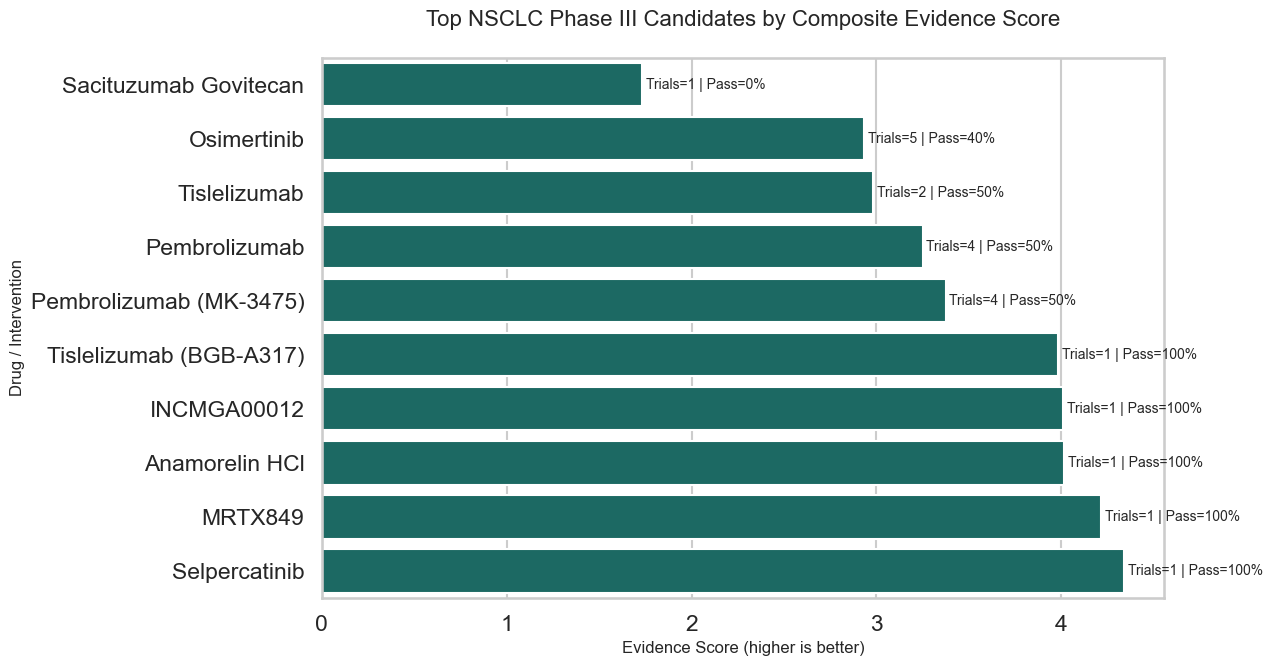

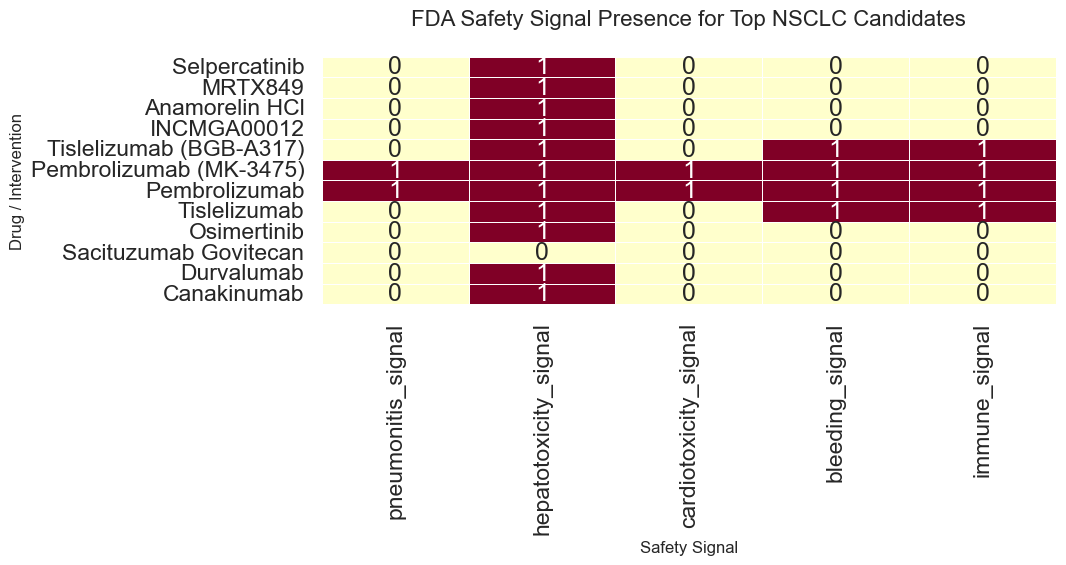

In [25]:
# Visual dashboard elements: efficacy ranking + FDA safety signal heatmap
palette_main = ["#0f766e", "#14b8a6", "#f59e0b", "#ef4444"]

fig, ax = plt.subplots(figsize=(13, 7))
plot_df = top_candidates.head(10).sort_values("evidence_score", ascending=True)
sns.barplot(data=plot_df, x="evidence_score", y="drug", color=palette_main[0], ax=ax)
ax.set_title("Top NSCLC Phase III Candidates by Composite Evidence Score\n")
ax.set_xlabel("Evidence Score (higher is better)")
ax.set_ylabel("Drug / Intervention")
for i, (_, r) in enumerate(plot_df.iterrows()):
    ax.text(r["evidence_score"] + 0.02, i, f"Trials={int(r['trial_count'])} | Pass={r['promising_rate']:.0%}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_EFFICACY, dpi=240, bbox_inches="tight")
plt.show()

signal_cols = ["pneumonitis_signal", "hepatotoxicity_signal", "cardiotoxicity_signal", "bleeding_signal", "immune_signal"]
if len(safety_df) > 0 and set(signal_cols).issubset(safety_df.columns):
    heat_df = safety_df.set_index("drug")[signal_cols]
    plt.figure(figsize=(11, 6))
    sns.heatmap(heat_df, cmap="YlOrRd", linewidths=0.5, cbar=False, annot=True, fmt="d")
    plt.title("FDA Safety Signal Presence for Top NSCLC Candidates\n")
    plt.xlabel("Safety Signal")
    plt.ylabel("Drug / Intervention")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIG_SAFETY, dpi=240, bbox_inches="tight")
    plt.show()
else:
    print("No FDA signal matrix available for heatmap.")

In [26]:
# Persist artifacts for portfolio use
qa_df.to_csv(OUTPUT_QA_CSV, index=False)
drug_ranking.to_csv(OUTPUT_RANKING_CSV, index=False)
safety_df.to_csv(OUTPUT_SAFETY_CSV, index=False)

with open(OUTPUT_QA_JSON, "w", encoding="utf-8") as f:
    json.dump(qa_records, f, ensure_ascii=False, indent=2)

print("Saved artifacts:")
print(f"- QA JSON: {OUTPUT_QA_JSON}")
print(f"- QA CSV: {OUTPUT_QA_CSV}")
print(f"- Drug ranking CSV: {OUTPUT_RANKING_CSV}")
print(f"- FDA safety CSV: {OUTPUT_SAFETY_CSV}")
print(f"- Figure: {OUTPUT_FIG_EFFICACY}")
print(f"- Figure: {OUTPUT_FIG_SAFETY}")

Saved artifacts:
- QA JSON: ..\data\processed\extractions\nsclc_rag_extraction_answers.json
- QA CSV: ..\data\processed\extractions\nsclc_rag_extraction_answers.csv
- Drug ranking CSV: ..\data\processed\extractions\nsclc_phase3_drug_ranking.csv
- FDA safety CSV: ..\data\processed\extractions\nsclc_fda_safety_summary.csv
- Figure: ..\reports\figures\05_nsclc_promising_candidates.png
- Figure: ..\reports\figures\05_nsclc_safety_signals.png
